In [1]:
import pandas as pd
import sys
sys.path.append("../..")

In [2]:
from paper.plotting_functions import plot_profile, plot_pareto
from paper.bench_utils import load

# Profile

In [3]:
name_map_profile = {  # allow list after ':'? and sum this
    "principled_clustering_diag": "Clustering",
    "clustering": "Clustering",
    "forward": "Sparse attention overall",
    "block_sparse_attention": "Attention computation",
    "assignment": "Cluster assignment",
    "compensate_query_to_mean": "Striped compensation",
}

In [4]:
def samples_to_profile_df(samples, patch_size=14):
    from collections import defaultdict
    grouped = defaultdict(list)
    for s in samples:
        timings = s.evals.get("timings", [])
        if not timings or not isinstance(timings, list):
            continue
        res = s.setup.get("resolution", s.setup.get("res"))
        n_tokens = (res // patch_size) ** 2
        totals = defaultdict(float)
        for name, val in timings:
            totals[name] += val
        grouped[n_tokens].append(dict(totals))

    rows = []
    for n_tokens, timing_list in grouped.items():
        all_keys = timing_list[0].keys()
        merged = {k: sum(t[k] for t in timing_list) / len(timing_list) for k in all_keys}
        rows.append({
            "n_tokens": n_tokens,
            "timings_profile": merged,
        })
    return pd.DataFrame(rows)

decompose
group_by_cluster
recompose
ungroup_back


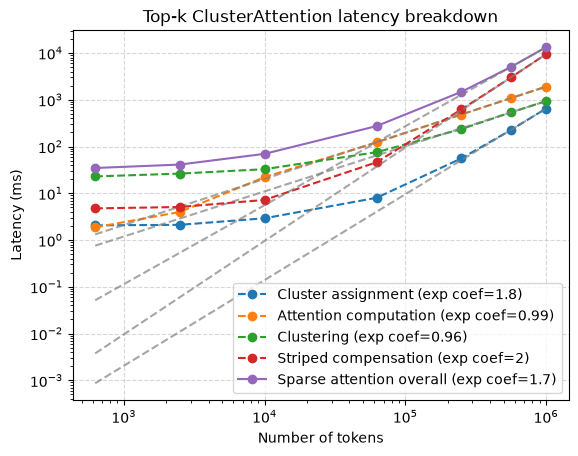

625 {'decompose': 6.242560029029846, 'clustering': 22.924810707569122, 'group_by_cluster': 0.5917973307271799, 'assignment': 2.0603306566675506, 'block_sparse_attention': 1.8683520058790843, 'compensate_query_to_mean': 4.751018663247426, 'ungroup_back': 0.9349226715664068, 'forward': 34.708181500434875, 'recompose': 3.5090986639261246}
2500 {'decompose': 6.3165119886398315, 'clustering': 26.34229338169098, 'group_by_cluster': 1.106175993879636, 'assignment': 2.1159466629227004, 'block_sparse_attention': 3.9845973501602807, 'compensate_query_to_mean': 5.090741331378619, 'ungroup_back': 0.9546133354306221, 'forward': 41.11420818169912, 'recompose': 3.4993493308623633}
10000 {'decompose': 5.99591463804245, 'clustering': 32.75884807109833, 'group_by_cluster': 2.8345066582163176, 'assignment': 2.92182399580876, 'block_sparse_attention': 22.140682637691498, 'compensate_query_to_mean': 7.211946656306584, 'ungroup_back': 1.2447679974138737, 'forward': 69.72119482358296, 'recompose': 4.27251200

In [5]:
samples = load("profile_64", "results")
#samples = load("profile_10perc", "results")
df = samples_to_profile_df(samples)
df = df.sort_values("n_tokens")
plot_profile({"": df}, skip_first=0, name_map=name_map_profile)
for i, row in df.iterrows():
    print(row["n_tokens"], row["timings_profile"])

# Sweep pareto

In [6]:
method_colors = {
    # dense
    "dense": "#777777",
    "dense_sage": "#000000",
    # clusterattention
    "clusterattention_topk": "#52b7fa",
    "clusterattention_topk_finecomp": "#005fb2",
    "clusterattention_adaptive": "#98df8a",
    "clusterattention_adaptive_finecomp": "#2ca02c",
    # random
    "random_topk": "#fb9a24",
    "random_topk_finecomp": "#eb7601",
    # svoo
    "svoo": "#9467bd",
    # spargeattn
    "spargeattn_topk": "#c0201c",
    "spargeattn_adaptive_m01": "#e85450",
    "spargeattn_adaptive_06": "#a01515",
}

ClusterAttention: 158.7 time units @ 0.99 metric units
ClusterAttention w/ SMC: 149.6 time units @ 0.99 metric units
SpargeAttn: 146.2 time units @ 0.99 metric units


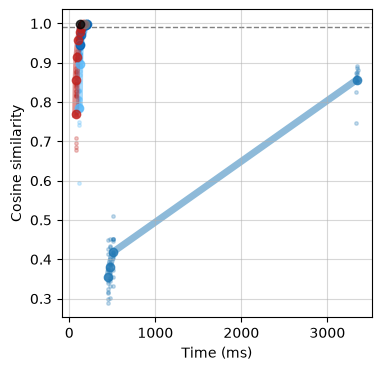

In [8]:
version = "v1"
size = "small"  # small, medium, large, None
kind = "div8k"  # None, deer, hamngatan, div8k
metric = "evals.per_patch_cosine_similarity.mean"
# evals.flattened_cosine_similarity, evals.per_patch_cosine_similarity.mean / p5

#########
## Run ##
#########

samples = load(version, "results")
df = pd.json_normalize([s.__dict__ for s in samples])
size_map = {
    "small": 2072,
    "medium": 3500,
    "large": 5306
}
if size:
    df = df[df["setup.resolution"] == size_map[size]]
kind_map = {
    "deer": (lambda df: df[df["setup.image"]=="deer"]),
    "hamngatan": (lambda df: df[df["setup.image"]=="hamngatan"]),
    "div8k": (lambda df: df[~df["setup.image"].isin(["deer", "hamngatan"])]),
}
if kind:
    df = kind_map[kind](df)
df = df.rename(columns={"name": "method", "latency": "time_ms", metric: "cosine_sim"})
df["param"] = df.apply(
    lambda row: row[f"setup.{row['sweep_param']}"] if pd.notna(row["sweep_param"]) else None,
    axis=1,
)
plot_pareto({"DINOv2": df}, show_annotations=False, show_legend=False, 
            #logx=True, 
    method_colors=method_colors, 
    name_map={
    "dense": "Dense",
    "dense_sage": "Dense using SageAttention",
    #"random_topk": "Random Clusters",
    #"random_topk_finecomp": "Random Clusters w/ SMC",
    "clusterattention_topk": "ClusterAttention",
    "clusterattention_topk_finecomp": "ClusterAttention w/ SMC",
    "spargeattn_topk": "SpargeAttn",
    "scatterbrain": "Scatterbrain"
})

ClusterAttention (adaptive): 2211.1 time units @ 0.99 metric units
SpargeAttn (adaptive, 0.6): 3759.3 time units @ 0.99 metric units
SpargeAttn (adaptive, -0.1): 3377.2 time units @ 0.99 metric units
SVOO: 6609.4 time units @ 0.99 metric units


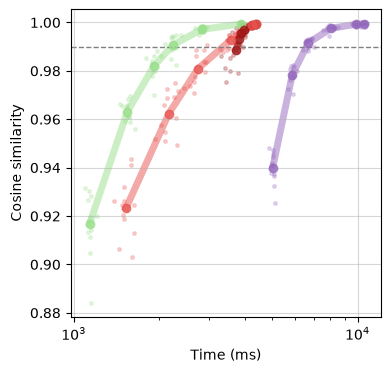

In [9]:
version = "v1"
size = "large"
kind = "div8k"
metric = "evals.per_patch_cosine_similarity.mean"

#########
## Run ##
#########

samples = load(version, "results")
df = pd.json_normalize([s.__dict__ for s in samples])
size_map = {
    "small": 2072,
    "medium": 3500,
    "large": 5306
}
if size:
    df = df[df["setup.resolution"] == size_map[size]]
kind_map = {
    "deer": (lambda df: df[df["setup.image"]=="deer"]),
    "hamngatan": (lambda df: df[df["setup.image"]=="hamngatan"]),
    "div8k": (lambda df: df[~df["setup.image"].isin(["deer", "hamngatan"])]),
}
if kind:
    df = kind_map[kind](df)
df = df.rename(columns={"name": "method", "latency": "time_ms", metric: "cosine_sim"})
df["param"] = df.apply(
    lambda row: row[f"setup.{row['sweep_param']}"] if pd.notna(row["sweep_param"]) else None,
    axis=1,
)
plot_pareto({"DINOv2": df}, show_annotations=False, show_legend=False, 
    method_colors=method_colors, 
    name_map={
    "svoo": "SVOO",
    "clusterattention_adaptive": "ClusterAttention (adaptive)",
    "spargeattn_adaptive_m01": "SpargeAttn (adaptive, -0.1)",
    "spargeattn_adaptive_06": "SpargeAttn (adaptive, 0.6)"
}, logx=True)

ClusterAttention w/ SMC: 173.1 time units @ 0.99 metric units
SpargeAttn: 203.2 time units @ 0.99 metric units


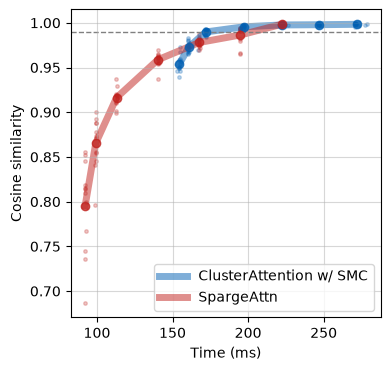

In [11]:
version = "threshold"
size = None
kind = "div8k"
metric = "evals.per_patch_cosine_similarity.mean"

#########
## Run ##
#########

samples = load(version, "results")
df = pd.json_normalize([s.__dict__ for s in samples])
size_map = {
    "small": 2072,
    "medium": 3500,
    "large": 5306
}
if size:
    df = df[df["setup.resolution"] == size_map[size]]
kind_map = {
    "deer": (lambda df: df[df["setup.image"]=="deer"]),
    "hamngatan": (lambda df: df[df["setup.image"]=="hamngatan"]),
    "div8k": (lambda df: df[~df["setup.image"].isin(["deer", "hamngatan"])]),
}
if kind:
    df = kind_map[kind](df)
df = df.rename(columns={"name": "method", "latency": "time_ms", metric: "cosine_sim"})
df["param"] = df.apply(
    lambda row: row[f"setup.{row['sweep_param']}"] if pd.notna(row["sweep_param"]) else None,
    axis=1,
)
plot_pareto({"DINOv2": df}, show_annotations=False, show_legend=True, 
    method_colors=method_colors,
    name_map={
    "clusterattention_topk_finecomp": "ClusterAttention w/ SMC",
    "spargeattn_topk": "SpargeAttn",
})